In [1]:
# =============================================================================
# CELL 1 — Imports & Config
# =============================================================================
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
 
# ── Paths (update these to point to your files) ──────────────────────────────
TX1_PATH  = "iq_samplesTX1.csv"   # TX1 raw IQ chunks
TX2_PATH  = "iq_samplesTX2.csv"   # TX2 raw IQ chunks  (provide when available)
AADD_PATH = "iq_Aadd.csv"         # Stage-A sum (TX1+TX2 added by your code)
BADD1_PATH = "iq_badd1.csv"       # Stage-B input 1 (zero-padded TX1)
BADD2_PATH = "iq_badd2.csv"       # Stage-B input 2 (zero-padded TX2) – provide when available
 
plt.rcParams.update({"figure.dpi": 130, "font.size": 9})
print("✅ Imports OK")

✅ Imports OK


In [2]:
# =============================================================================
# CELL 2 — Generic loader: parse list-strings → flat numpy complex array
# =============================================================================
def parse_iq_list(s):
    """Parse a stringified Python list into a numpy float array."""
    return np.array(ast.literal_eval(s), dtype=np.float64)
 
def load_iq_file(path):
    """
    Load an IQ CSV.
 
    Returns a DataFrame with extra columns:
        i_arr  – numpy array of I samples for that chunk
        q_arr  – numpy array of Q samples for that chunk
        ts_dt  – timestamp as datetime object
        t_start – timestamp as float seconds (for alignment)
    """
    df = pd.read_csv(path)
    df["ts_dt"]   = pd.to_datetime(df["timestamp"])
    df["t_start"] = df["ts_dt"].astype(np.int64) / 1e9   # UNIX seconds (float)
    df["i_arr"]   = df["i_values"].apply(parse_iq_list)
    df["q_arr"]   = df["q_values"].apply(parse_iq_list)
    # Sanity: num_samples should match parsed array length
    mismatch = df.apply(lambda r: len(r["i_arr"]) != r["num_samples"], axis=1).sum()
    if mismatch:
        print(f"  ⚠️  {mismatch} rows have num_samples ≠ len(i_arr) in {path}")
    return df
 
def flatten_to_timeline(df, label=""):
    """
    Expand chunk-based DataFrame into a single 1-D timeline.
 
    Uses sample_index as the authoritative position (so gaps between
    chunks become real gaps in the output array).
 
    Returns:
        i_full, q_full  – 1-D numpy arrays (zeros where no sample present)
        sample_offset   – integer, the global sample_index of position 0
    """
    if df.empty:
        return np.array([]), np.array([]), 0
 
    min_idx = int(df["sample_index"].min())
    # last chunk's sample_index + its length
    last_row   = df.loc[df["sample_index"].idxmax()]
    max_idx    = int(last_row["sample_index"]) + len(last_row["i_arr"])
    total_len  = max_idx - min_idx
 
    i_full = np.zeros(total_len, dtype=np.float64)
    q_full = np.zeros(total_len, dtype=np.float64)
 
    for _, row in df.iterrows():
        start = int(row["sample_index"]) - min_idx
        n     = len(row["i_arr"])
        i_full[start:start + n] = row["i_arr"]
        q_full[start:start + n] = row["q_arr"]
 
    print(f"  [{label}] total samples: {total_len:,}  | "
          f"nonzero I: {np.count_nonzero(i_full):,}  | "
          f"nonzero Q: {np.count_nonzero(q_full):,}")
    return i_full, q_full, min_idx
 
print("✅ Helper functions defined")
 

✅ Helper functions defined


In [3]:
# =============================================================================
# CELL 3 — Load TX1 (and TX2 when available)
# =============================================================================
print("Loading TX1 …")
tx1_df = load_iq_file(TX1_PATH)
 
# ── TX2 (comment this block out if file not yet available) ───────────────────
try:
    print("Loading TX2 …")
    tx2_df = load_iq_file(TX2_PATH)
    HAS_TX2 = True
except FileNotFoundError:
    print("  ⚠️  TX2 file not found – will use zeros as TX2 placeholder")
    tx2_df  = pd.DataFrame()   # empty sentinel
    HAS_TX2 = False
 
print(f"\nTX1 chunks : {len(tx1_df)}")
print(f"TX2 chunks : {len(tx2_df) if HAS_TX2 else 'N/A'}")
print("\nTX1 head:")
display(tx1_df[["sample_index", "timestamp", "num_samples"]].head(10))
 
 

Loading TX1 …
Loading TX2 …

TX1 chunks : 6
TX2 chunks : 6

TX1 head:


,sample_index,timestamp,num_samples
0,0,2026-04-20 17:16:08.336,1024
1,1024,2026-04-20 17:16:08.339,128
2,1152,2026-04-20 17:16:09.206,1024
3,2176,2026-04-20 17:16:09.211,128
4,2304,2026-04-20 17:16:09.420,1024
5,3328,2026-04-20 17:16:09.423,128


In [4]:
# =============================================================================
# CELL 4 — Flatten TX1 & TX2 onto a common timeline, compute Stage-A sum
# =============================================================================
print("Flattening TX1 …")
tx1_i, tx1_q, tx1_offset = flatten_to_timeline(tx1_df, "TX1")
 
if HAS_TX2:
    print("Flattening TX2 …")
    tx2_i, tx2_q, tx2_offset = flatten_to_timeline(tx2_df, "TX2")
else:
    # Placeholder: match TX1 length, all zeros
    tx2_i = np.zeros_like(tx1_i)
    tx2_q = np.zeros_like(tx1_q)
    tx2_offset = tx1_offset
 
# ── Align TX1 and TX2 on a shared sample grid ────────────────────────────────
global_min   = min(tx1_offset, tx2_offset)
global_max   = max(tx1_offset + len(tx1_i), tx2_offset + len(tx2_i))
total_shared = global_max - global_min
 
tx1_i_aligned = np.zeros(total_shared)
tx1_q_aligned = np.zeros(total_shared)
tx2_i_aligned = np.zeros(total_shared)
tx2_q_aligned = np.zeros(total_shared)
 
s1 = tx1_offset - global_min
tx1_i_aligned[s1:s1 + len(tx1_i)] = tx1_i
tx1_q_aligned[s1:s1 + len(tx1_q)] = tx1_q
 
s2 = tx2_offset - global_min
tx2_i_aligned[s2:s2 + len(tx2_i)] = tx2_i
tx2_q_aligned[s2:s2 + len(tx2_q)] = tx2_q
 
# ── Stage-A result: element-wise sum ─────────────────────────────────────────
stageA_i = tx1_i_aligned + tx2_i_aligned
stageA_q = tx1_q_aligned + tx2_q_aligned
stageA_power_db = 10 * np.log10(stageA_i**2 + stageA_q**2 + 1e-20)  # dBFS-like
 
print(f"\nShared timeline length : {total_shared:,} samples")
print(f"Stage-A nonzero I      : {np.count_nonzero(stageA_i):,}")
print("✅ Stage-A reference sum computed")
 

Flattening TX1 …
  [TX1] total samples: 3,456  | nonzero I: 3,456  | nonzero Q: 0
Flattening TX2 …
  [TX2] total samples: 3,456  | nonzero I: 3,456  | nonzero Q: 0

Shared timeline length : 3,456 samples
Stage-A nonzero I      : 3,117
✅ Stage-A reference sum computed


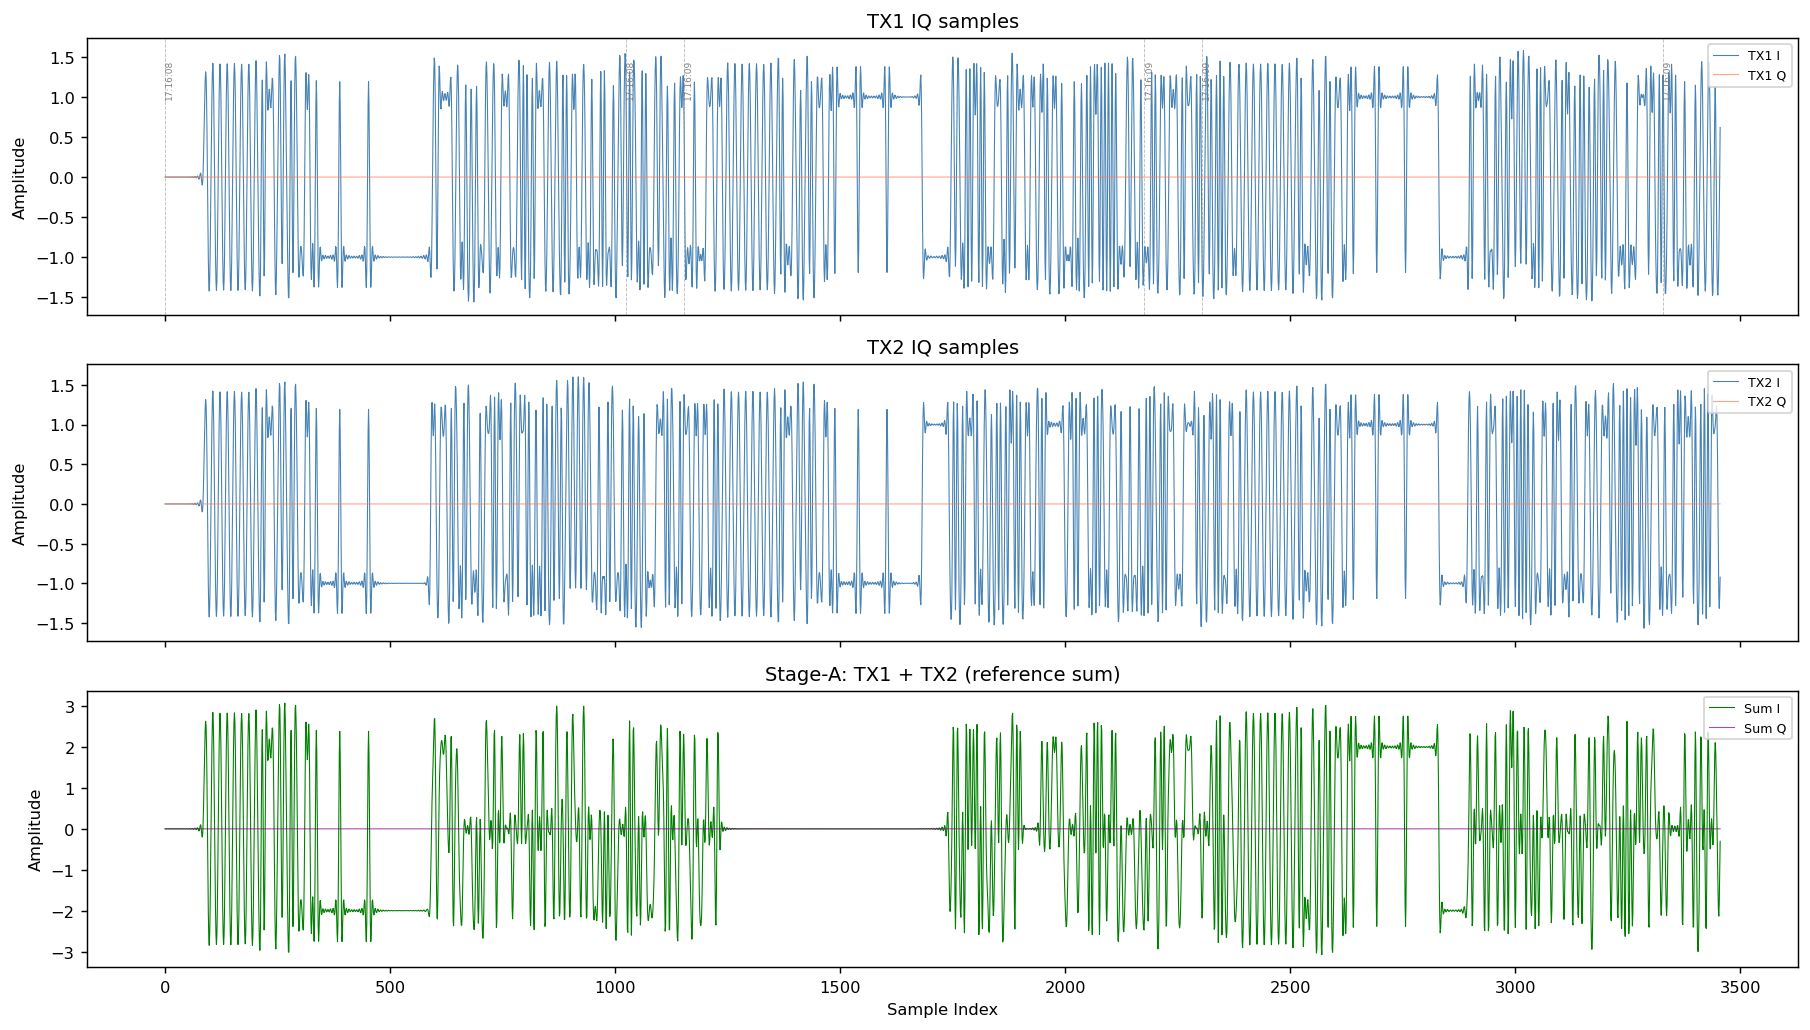

✅ Plot saved → stage_A_tx_plot.png


In [5]:
# =============================================================================
# CELL 5 — Plot TX1 / TX2 amplitude vs. sample_index (with timestamps)
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
sample_axis = np.arange(total_shared) + global_min
 
axes[0].plot(sample_axis, tx1_i_aligned, linewidth=0.6, color="steelblue", label="TX1 I")
axes[0].plot(sample_axis, tx1_q_aligned, linewidth=0.6, color="coral",     label="TX1 Q", alpha=0.7)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("TX1 IQ samples")
axes[0].legend(loc="upper right", fontsize=7)
 
axes[1].plot(sample_axis, tx2_i_aligned, linewidth=0.6, color="steelblue", label="TX2 I")
axes[1].plot(sample_axis, tx2_q_aligned, linewidth=0.6, color="coral",     label="TX2 Q", alpha=0.7)
axes[1].set_ylabel("Amplitude")
axes[1].set_title("TX2 IQ samples" + (" (placeholder zeros)" if not HAS_TX2 else ""))
axes[1].legend(loc="upper right", fontsize=7)
 
axes[2].plot(sample_axis, stageA_i, linewidth=0.6, color="green",  label="Sum I")
axes[2].plot(sample_axis, stageA_q, linewidth=0.6, color="purple", label="Sum Q", alpha=0.7)
axes[2].set_ylabel("Amplitude")
axes[2].set_title("Stage-A: TX1 + TX2 (reference sum)")
axes[2].set_xlabel("Sample Index")
axes[2].legend(loc="upper right", fontsize=7)
 
# ── Annotate TX1 chunk timestamps on top panel ───────────────────────────────
for _, row in tx1_df.iterrows():
    axes[0].axvline(row["sample_index"], color="gray", lw=0.5, ls="--", alpha=0.5)
    axes[0].text(row["sample_index"], axes[0].get_ylim()[1] * 0.85,
                 row["timestamp"].split(".")[0].split(" ")[1],  # HH:MM:SS
                 fontsize=5, rotation=90, color="gray", va="top")
 
plt.tight_layout()
plt.savefig("stage_A_tx_plot.png", bbox_inches="tight")
plt.show()
print("✅ Plot saved → stage_A_tx_plot.png")
 

In [6]:
# =============================================================================
# CELL 6 — Load Stage-B files (badd1 and badd2 with zero-padding)
# =============================================================================
print("Loading badd1 …")
badd1_df = load_iq_file(BADD1_PATH)
 
try:
    print("Loading badd2 …")
    badd2_df = load_iq_file(BADD2_PATH)
    HAS_BADD2 = True
except FileNotFoundError:
    print("  ⚠️  badd2 file not found – will use zeros as badd2 placeholder")
    badd2_df  = pd.DataFrame()
    HAS_BADD2 = False
 
print(f"\nbadd1 chunks : {len(badd1_df)}")
print(f"badd2 chunks : {len(badd2_df) if HAS_BADD2 else 'N/A'}")
print("\nbadd1 head:")
display(badd1_df[["sample_index", "timestamp", "num_samples"]].head(10))

Loading badd1 …
Loading badd2 …

badd1 chunks : 172
badd2 chunks : 111

badd1 head:


,sample_index,timestamp,num_samples
0,0,2026-04-20 17:16:06.971,4096
1,4096,2026-04-20 17:16:06.979,4095
2,8191,2026-04-20 17:16:06.986,4096
3,12287,2026-04-20 17:16:06.992,4095
4,16382,2026-04-20 17:16:07.014,4096
5,20478,2026-04-20 17:16:07.091,4093
6,24571,2026-04-20 17:16:07.097,2
7,24573,2026-04-20 17:16:07.186,4094
8,28667,2026-04-20 17:16:07.193,2
9,28669,2026-04-20 17:16:07.261,4090


In [7]:
# =============================================================================
# CELL 7 — Flatten badd1 & badd2, compute Stage-B sum
# =============================================================================
print("Flattening badd1 …")
b1_i, b1_q, b1_offset = flatten_to_timeline(badd1_df, "badd1")
 
if HAS_BADD2:
    print("Flattening badd2 …")
    b2_i, b2_q, b2_offset = flatten_to_timeline(badd2_df, "badd2")
else:
    b2_i      = np.zeros_like(b1_i)
    b2_q      = np.zeros_like(b1_q)
    b2_offset = b1_offset
 
# ── Align badd1 + badd2 ──────────────────────────────────────────────────────
b_global_min = min(b1_offset, b2_offset)
b_global_max = max(b1_offset + len(b1_i), b2_offset + len(b2_i))
b_total      = b_global_max - b_global_min
 
b1_i_aligned = np.zeros(b_total)
b1_q_aligned = np.zeros(b_total)
b2_i_aligned = np.zeros(b_total)
b2_q_aligned = np.zeros(b_total)
 
sb1 = b1_offset - b_global_min
b1_i_aligned[sb1:sb1 + len(b1_i)] = b1_i
b1_q_aligned[sb1:sb1 + len(b1_q)] = b1_q
 
sb2 = b2_offset - b_global_min
b2_i_aligned[sb2:sb2 + len(b2_i)] = b2_i
b2_q_aligned[sb2:sb2 + len(b2_q)] = b2_q
 
stageB_i = b1_i_aligned + b2_i_aligned
stageB_q = b1_q_aligned + b2_q_aligned
 
print(f"\nStage-B timeline length : {b_total:,} samples")
print(f"Stage-B nonzero I       : {np.count_nonzero(stageB_i):,}")
print("✅ Stage-B sum computed")

Flattening badd1 …
  [badd1] total samples: 446,410  | nonzero I: 2,304  | nonzero Q: 1,035
Flattening badd2 …
  [badd2] total samples: 446,410  | nonzero I: 2,304  | nonzero Q: 1,054

Stage-B timeline length : 446,410 samples
Stage-B nonzero I       : 4,608
✅ Stage-B sum computed


In [8]:
# =============================================================================
# CELL 8 — Align Stage-A and Stage-B on a common grid and compare
# =============================================================================
# ── Build absolute sample positions using the global_min from each stage ─────
a_abs_start = global_min     # Stage-A global sample offset
b_abs_start = b_global_min   # Stage-B global sample offset
 
comp_min = min(a_abs_start, b_abs_start)
comp_max = max(a_abs_start + len(stageA_i), b_abs_start + len(stageB_i))
comp_len = comp_max - comp_min
 
compA_i = np.zeros(comp_len)
compA_q = np.zeros(comp_len)
compB_i = np.zeros(comp_len)
compB_q = np.zeros(comp_len)
 
offA = a_abs_start - comp_min
compA_i[offA:offA + len(stageA_i)] = stageA_i
compA_q[offA:offA + len(stageA_q)] = stageA_q
 
offB = b_abs_start - comp_min
compB_i[offB:offB + len(stageB_i)] = stageB_i
compB_q[offB:offB + len(stageB_q)] = stageB_q
 
# ── Difference ────────────────────────────────────────────────────────────────
diff_i = compA_i - compB_i
diff_q = compA_q - compB_q
 
# ── Power (dBFS) ─────────────────────────────────────────────────────────────
def power_db(i, q, eps=1e-20):
    return 10 * np.log10(i**2 + q**2 + eps)
 
pA_db   = power_db(compA_i, compA_q)
pB_db   = power_db(compB_i, compB_q)
pdiff   = pA_db - pB_db   # should be ~0 dB where signals overlap
 
comp_axis = np.arange(comp_len) + comp_min
 
# ── Metrics ───────────────────────────────────────────────────────────────────
active_mask = (np.abs(compA_i) > 0) | (np.abs(compB_i) > 0)
rmse_i = np.sqrt(np.mean(diff_i[active_mask]**2)) if active_mask.any() else 0
rmse_q = np.sqrt(np.mean(diff_q[active_mask]**2)) if active_mask.any() else 0
max_diff_i = np.max(np.abs(diff_i[active_mask])) if active_mask.any() else 0
 
print(f"Comparison grid length : {comp_len:,} samples")
print(f"Active (nonzero) mask  : {active_mask.sum():,} samples")
print(f"RMSE (I channel)       : {rmse_i:.6f}")
print(f"RMSE (Q channel)       : {rmse_q:.6f}")
print(f"Max |diff| I           : {max_diff_i:.6f}")
print()
if rmse_i < 1e-6:
    print("✅ Stage-A and Stage-B match — RF addition is consistent!")
else:
    print("⚠️  Non-trivial difference detected — check alignment & zero-padding logic")

Comparison grid length : 446,410 samples
Active (nonzero) mask  : 7,725 samples
RMSE (I channel)       : 1.249869
RMSE (Q channel)       : 0.000000
Max |diff| I           : 3.072459

⚠️  Non-trivial difference detected — check alignment & zero-padding logic


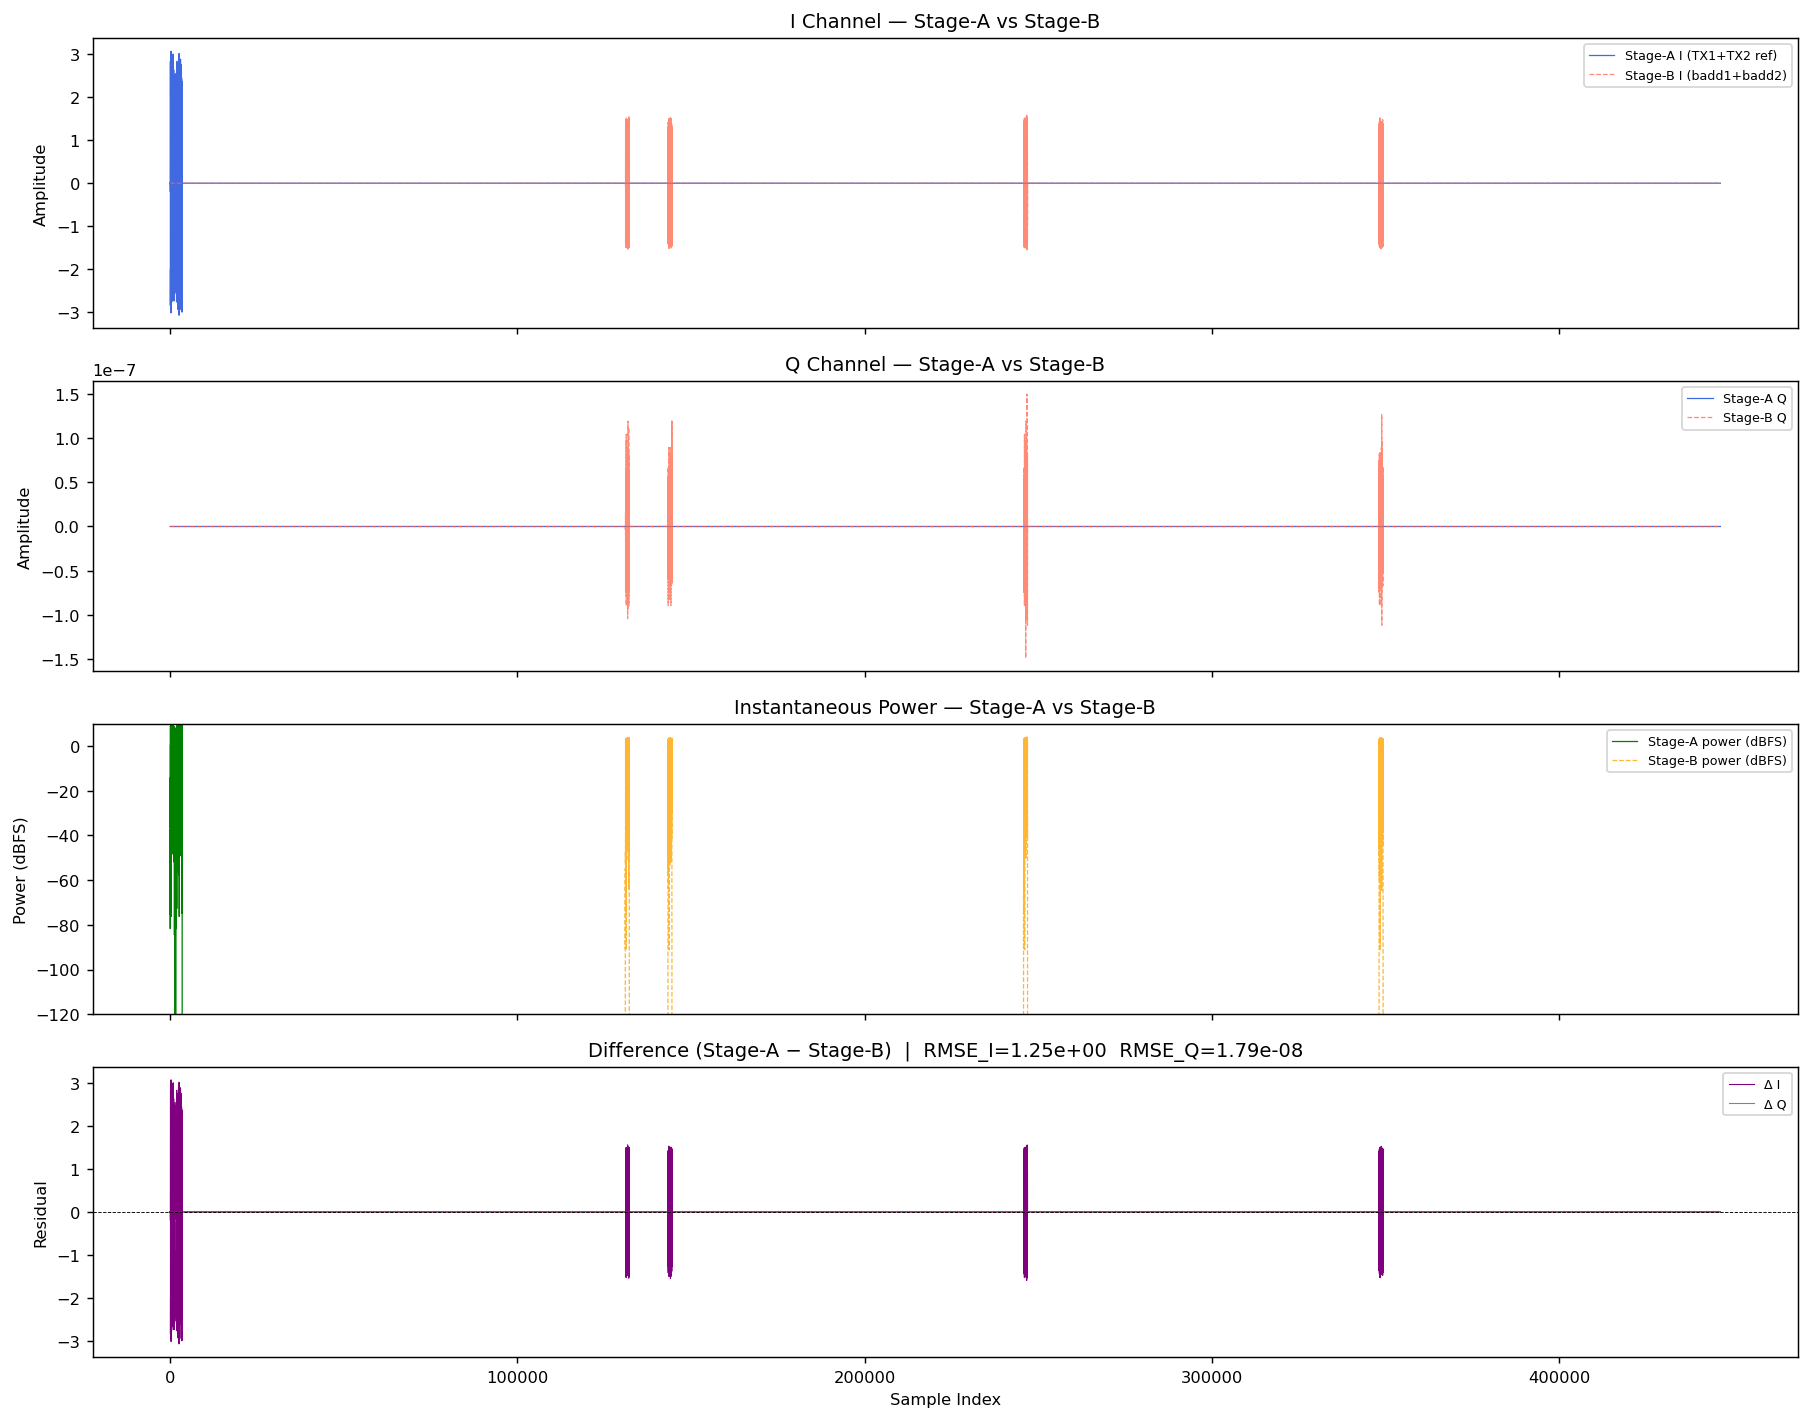

✅ Plot saved → stage_AB_comparison.png


In [9]:
# =============================================================================
# CELL 9 — Comparison plot: Stage-A vs Stage-B
# =============================================================================
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
 
# Panel 1: I channel overlay
axes[0].plot(comp_axis, compA_i, lw=0.7, color="royalblue", label="Stage-A I (TX1+TX2 ref)")
axes[0].plot(comp_axis, compB_i, lw=0.7, color="tomato",    label="Stage-B I (badd1+badd2)", alpha=0.75, ls="--")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("I Channel — Stage-A vs Stage-B")
axes[0].legend(fontsize=7)
 
# Panel 2: Q channel overlay
axes[1].plot(comp_axis, compA_q, lw=0.7, color="royalblue", label="Stage-A Q")
axes[1].plot(comp_axis, compB_q, lw=0.7, color="tomato",    label="Stage-B Q", alpha=0.75, ls="--")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Q Channel — Stage-A vs Stage-B")
axes[1].legend(fontsize=7)
 
# Panel 3: Power (dBFS)
axes[2].plot(comp_axis, pA_db, lw=0.7, color="green",  label="Stage-A power (dBFS)")
axes[2].plot(comp_axis, pB_db, lw=0.7, color="orange", label="Stage-B power (dBFS)", alpha=0.8, ls="--")
axes[2].set_ylabel("Power (dBFS)")
axes[2].set_title("Instantaneous Power — Stage-A vs Stage-B")
axes[2].legend(fontsize=7)
axes[2].set_ylim([-120, 10])   # adjust range if needed
 
# Panel 4: Residual difference
axes[3].plot(comp_axis, diff_i, lw=0.6, color="purple", label="Δ I")
axes[3].plot(comp_axis, diff_q, lw=0.6, color="brown",  label="Δ Q", alpha=0.7)
axes[3].axhline(0, color="black", lw=0.5, ls="--")
axes[3].set_ylabel("Residual")
axes[3].set_title(f"Difference (Stage-A − Stage-B)  |  RMSE_I={rmse_i:.2e}  RMSE_Q={rmse_q:.2e}")
axes[3].set_xlabel("Sample Index")
axes[3].legend(fontsize=7)
 
plt.tight_layout()
plt.savefig("stage_AB_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Plot saved → stage_AB_comparison.png")
 

In [10]:
# =============================================================================
# CELL 10 — Power-level addition sanity check (key RF verification)
#
# Added for debugging:
# When two equal-power uncorrelated signals add, power should increase by ~3 dB.
# When they are coherent (same phase), it increases by 6 dB.
# This cell measures that and flags anomalies.
# =============================================================================
def rms_power_db(i_arr, q_arr, mask=None):
    """Return RMS power in dB over active samples."""
    mag2 = i_arr**2 + q_arr**2
    if mask is not None:
        mag2 = mag2[mask]
    mag2 = mag2[mag2 > 0]
    if len(mag2) == 0:
        return -np.inf
    return 10 * np.log10(np.mean(mag2))
 
# Active mask for each stage (where at least one signal is nonzero)
tx1_mask = (np.abs(tx1_i_aligned) > 0) | (np.abs(tx1_q_aligned) > 0)
tx2_mask = (np.abs(tx2_i_aligned) > 0) | (np.abs(tx2_q_aligned) > 0)
sum_mask  = tx1_mask | tx2_mask
 
pwr_tx1  = rms_power_db(tx1_i_aligned, tx1_q_aligned, tx1_mask)
pwr_tx2  = rms_power_db(tx2_i_aligned, tx2_q_aligned, tx2_mask)
pwr_sum  = rms_power_db(stageA_i,      stageA_q,      sum_mask)
 
# Stage-B individual contributions
b1_mask = (np.abs(b1_i_aligned) > 0) | (np.abs(b1_q_aligned) > 0)
b2_mask = (np.abs(b2_i_aligned) > 0) | (np.abs(b2_q_aligned) > 0)
bsum_mask = b1_mask | b2_mask
 
pwr_b1   = rms_power_db(b1_i_aligned, b1_q_aligned, b1_mask)
pwr_b2   = rms_power_db(b2_i_aligned, b2_q_aligned, b2_mask)
pwr_bsum = rms_power_db(stageB_i,     stageB_q,     bsum_mask)
 
print("=" * 55)
print("  RF Power Addition Verification")
print("=" * 55)
print(f"  TX1 RMS power        : {pwr_tx1:+.2f} dBFS")
print(f"  TX2 RMS power        : {pwr_tx2:+.2f} dBFS")
print(f"  Stage-A sum power    : {pwr_sum:+.2f} dBFS")
if pwr_tx1 > -np.inf and pwr_tx2 > -np.inf:
    expected_3db = 10*np.log10(10**(pwr_tx1/10) + 10**(pwr_tx2/10))
    print(f"  Expected sum (linear): {expected_3db:+.2f} dBFS")
    delta_A = pwr_sum - expected_3db
    print(f"  Deviation Stage-A    : {delta_A:+.2f} dB  {'✅' if abs(delta_A) < 0.5 else '⚠️'}")
print()
print(f"  badd1 RMS power      : {pwr_b1:+.2f} dBFS")
print(f"  badd2 RMS power      : {pwr_b2:+.2f} dBFS")
print(f"  Stage-B sum power    : {pwr_bsum:+.2f} dBFS")
print()
print(f"  Stage-A vs Stage-B   : {pwr_sum - pwr_bsum:+.2f} dB  {'✅' if abs(pwr_sum - pwr_bsum) < 0.5 else '⚠️'}")
print("=" * 55)

  RF Power Addition Verification
  TX1 RMS power        : -0.11 dBFS
  TX2 RMS power        : -0.11 dBFS
  Stage-A sum power    : +3.91 dBFS
  Expected sum (linear): +2.90 dBFS
  Deviation Stage-A    : +1.02 dB  ⚠️

  badd1 RMS power      : -0.21 dBFS
  badd2 RMS power      : -0.21 dBFS
  Stage-B sum power    : -0.21 dBFS

  Stage-A vs Stage-B   : +4.12 dB  ⚠️


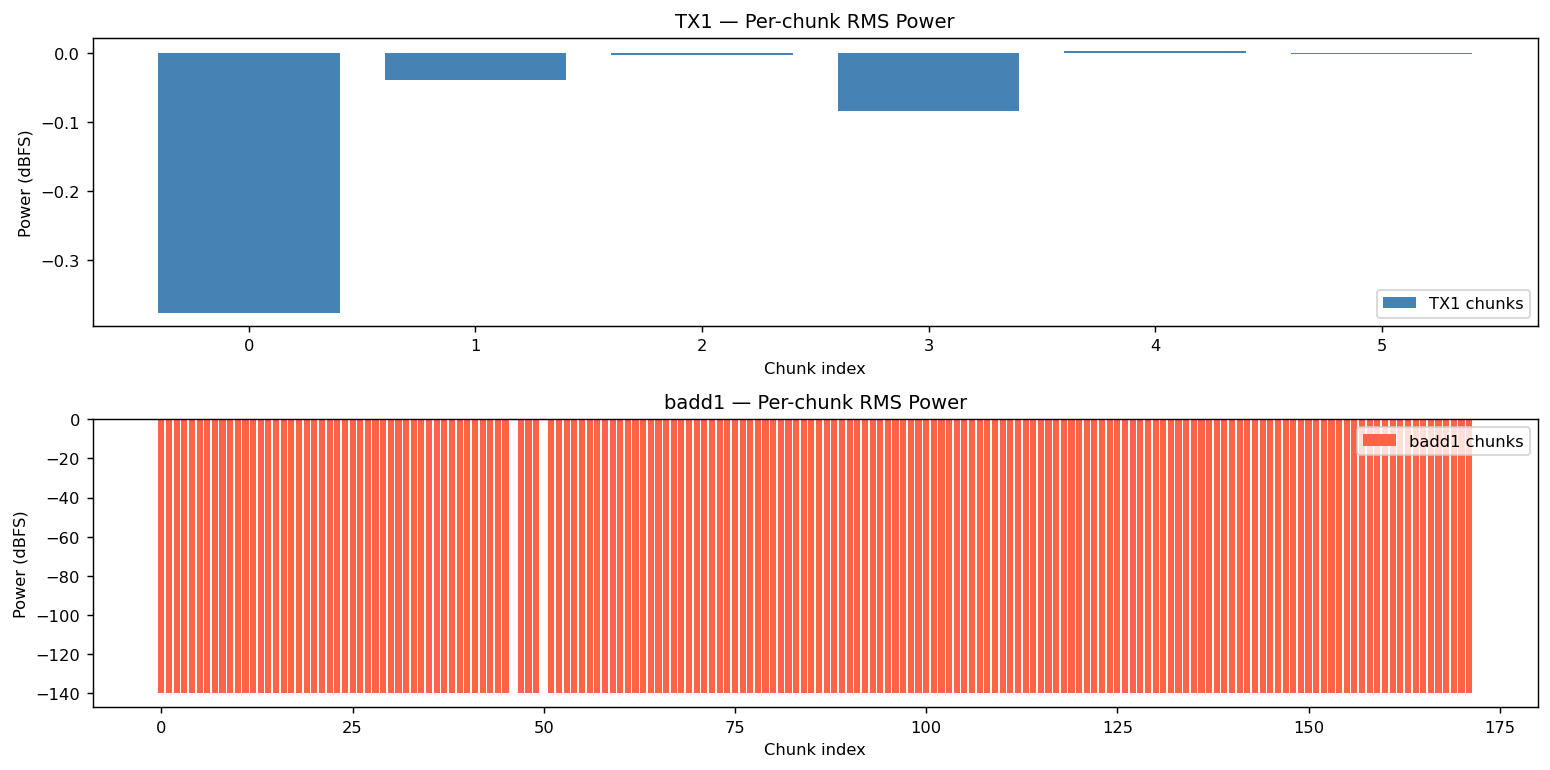

✅ Per-chunk power plot saved → per_chunk_power.png


In [11]:
# =============================================================================
# CELL 11 — Per-chunk power bar chart (useful with larger payloads)
#
# Added for debugging:
# Lets you see power chunk-by-chunk so you can spot if any chunk is
# missing, misaligned, or has wrong amplitude after addition.
# =============================================================================
def chunk_powers(df, label):
    rows = []
    for _, row in df.iterrows():
        i = row["i_arr"]
        q = row["q_arr"]
        mag2 = i**2 + q**2
        active = mag2[mag2 > 0]
        pwr = 10*np.log10(np.mean(active)) if len(active) > 0 else np.nan
        rows.append({"sample_index": row["sample_index"],
                     "timestamp":    row["timestamp"],
                     "pwr_db":       pwr,
                     "n_nonzero":    len(active),
                     "n_total":      len(i)})
    return pd.DataFrame(rows)
 
pwr_tx1_chunks  = chunk_powers(tx1_df, "TX1")
pwr_b1_chunks   = chunk_powers(badd1_df, "badd1")
 
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
 
axes[0].bar(range(len(pwr_tx1_chunks)), pwr_tx1_chunks["pwr_db"].fillna(-140),
            color="steelblue", label="TX1 chunks")
axes[0].set_title("TX1 — Per-chunk RMS Power")
axes[0].set_ylabel("Power (dBFS)")
axes[0].set_xlabel("Chunk index")
axes[0].legend()
 
axes[1].bar(range(len(pwr_b1_chunks)), pwr_b1_chunks["pwr_db"].fillna(-140),
            color="tomato", label="badd1 chunks")
axes[1].set_title("badd1 — Per-chunk RMS Power")
axes[1].set_ylabel("Power (dBFS)")
axes[1].set_xlabel("Chunk index")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("per_chunk_power.png", bbox_inches="tight")
plt.show()
print("✅ Per-chunk power plot saved → per_chunk_power.png")

Cross-correlation best lag : -49999 samples
⚠️  Offset of -49999 samples detected — adjust sample_index alignment or timestamp reference


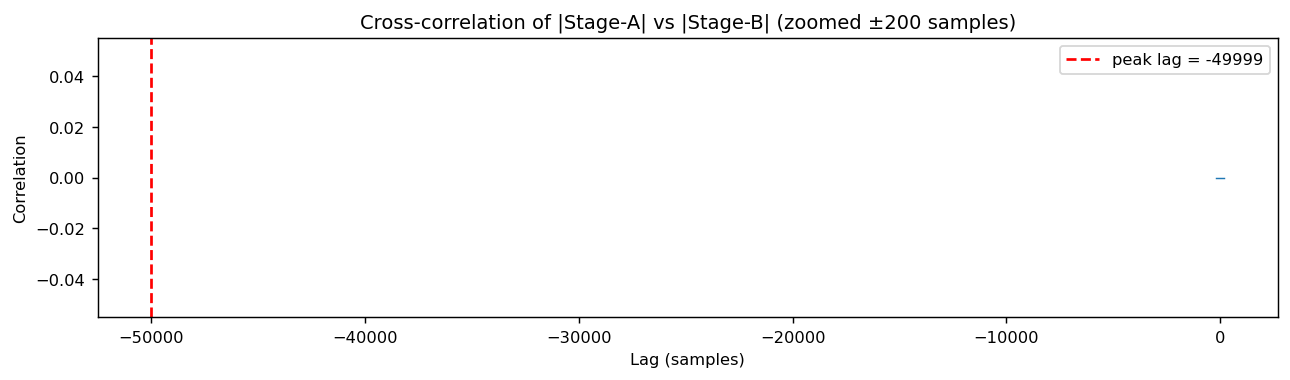

✅ Cross-correlation plot saved → xcorr_alignment.png


In [12]:
# =============================================================================
# CELL 12 — Cross-correlation alignment check (added for debugging)
#
# Why: If the timestamps between Stage-A and Stage-B are slightly offset
# (e.g. due to buffering latency), a cross-correlation on the magnitude
# envelopes will reveal the true sample offset so you can correct it.
# This is especially useful when payloads grow and the signals spread
# across many more chunks.
# =============================================================================
from scipy.signal import correlate
 
# Use magnitude envelopes for correlation (more robust than raw I)
env_A = np.abs(compA_i + 1j * compA_q)
env_B = np.abs(compB_i + 1j * compB_q)
 
# Limit to first 50k samples to keep correlation fast; increase for large payloads
N_CORR = min(50_000, len(env_A), len(env_B))
corr   = correlate(env_A[:N_CORR], env_B[:N_CORR], mode="full")
lags   = np.arange(-(N_CORR - 1), N_CORR)
best_lag = lags[np.argmax(corr)]
 
print(f"Cross-correlation best lag : {best_lag} samples")
if best_lag == 0:
    print("✅ Stage-A and Stage-B are already aligned at sample level")
else:
    print(f"⚠️  Offset of {best_lag} samples detected — "
          f"adjust sample_index alignment or timestamp reference")
 
fig, ax = plt.subplots(figsize=(10, 3))
lag_range = slice(N_CORR - 200, N_CORR + 200)   # zoom in around zero-lag
ax.plot(lags[lag_range], corr[lag_range], lw=0.8)
ax.axvline(best_lag, color="red", ls="--", label=f"peak lag = {best_lag}")
ax.set_title("Cross-correlation of |Stage-A| vs |Stage-B| (zoomed ±200 samples)")
ax.set_xlabel("Lag (samples)")
ax.set_ylabel("Correlation")
ax.legend()
plt.tight_layout()
plt.savefig("xcorr_alignment.png", bbox_inches="tight")
plt.show()
print("✅ Cross-correlation plot saved → xcorr_alignment.png")